# ABSA Preprocessing

This notebook prepares the data for **Aspect-Based Sentiment Analysis (ABSA)**.
It cleans review text, parses the aspect annotations, and creates:

- `train_preprocessed`: one row per review
- `train_absa`: one row per `(review, aspect)` pair
- `validation_absa`: validation set in the same format


In [13]:
import re
import ast
import json
import numpy as np
import pandas as pd

from camel_tools.utils.normalize import (
    normalize_alef_ar,
    normalize_alef_maksura_ar,
    normalize_teh_marbuta_ar,
)
from camel_tools.utils.dediac import dediac_ar
from camel_tools.tokenizers.word import simple_word_tokenize

pd.set_option('display.max_colwidth', 200)

train_df = pd.read_excel('train_fixed.xlsx')
valid_df = pd.read_excel('validation_fixed.xlsx')
unlabeled_df = pd.read_excel('unlabeled_fixed.xlsx')

print('train shape    :', train_df.shape)
print('validation shape:', valid_df.shape)
print('unlabeled shape :', unlabeled_df.shape)
train_df.head()

train shape    : (1971, 9)
validation shape: (500, 9)
unlabeled shape : (7047, 7)


,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""negative""}"
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق الممتاز والجو جميل مكان اكتر من رائع بصراحة ❤️❤️❤️❤️,5,قبل يومين (2),ممشي مصر Mawlana Cafe,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""positive"", ""service"": ""positive""}"
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالولي نص ساعة فعد ساعة ونص\nالاكل يعني كويس ولكن كمية قليلة جدا,1,قبل شهر,بيت لحم Beet Lahm,مطعم,google_maps,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative"", ""food"": ""neutral""}"
3,3024,احلي مكان فزايد,5,قبل شهر,ذا بلكون كافيه الشيخ زايد,مطعم مأكولات ومشروبات,google_maps,"[""general""]","{""general"": ""positive""}"
4,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا يعتبر من احسن الاسعار\n\nالبيتزا للاسف ما فيش اوبشن تختار عجينه سميكه ولا رفيعه كلها رفيعه\nحتس لو طلبتها سميكه هتجيلك رفيعه\nانما الحشو تمام و طعم ح...,4,قبل سنة,The Best Restaurant,مطعم,google_maps,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}"


In [14]:
valid_df.isna().sum()

review_id            0
review_text          0
star_rating          0
date                 0
business_name        0
business_category    0
platform             0
aspects              0
aspect_sentiments    0
dtype: int64

In [11]:
!pip install camel-tools

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/608.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/608.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/608.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/608.4 kB ? eta -:--:--
   ----------------- --

In [15]:
SENTIMENT_MAP = {'negative': 0, 'neutral': 1, 'positive': 2}
REVERSE_SENTIMENT_MAP = {v: k for k, v in SENTIMENT_MAP.items()}

ARABIC_RE = re.compile(r'[\u0600-\u06FF]')

def contains_arabic(text):
    return bool(ARABIC_RE.search(str(text)))

def normalize_arabic_with_camel(text):
    text = str(text)
    text = dediac_ar(text)
    text = normalize_alef_ar(text)
    text = normalize_alef_maksura_ar(text)
    text = normalize_teh_marbuta_ar(text)
    text = re.sub(r'ـ+', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return text

def clean_arabic_text(text):
    text = str(text)
    text = text.replace('\n', ' ')
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = normalize_arabic_with_camel(text)
    tokens = simple_word_tokenize(text)
    text = ' '.join(tokens)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_non_arabic_text(text):
    text = str(text).lower()
    text = text.replace('\n', ' ')
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    if contains_arabic(text):
        return clean_arabic_text(text)
    return clean_non_arabic_text(text)

def safe_parse(value, default):
    if pd.isna(value):
        return default
    if isinstance(value, (list, dict)):
        return value
    value = str(value).strip()
    if not value:
        return default
    try:
        return json.loads(value)
    except Exception:
        try:
            return ast.literal_eval(value)
        except Exception:
            return default

def parse_aspects(value):
    parsed = safe_parse(value, [])
    if isinstance(parsed, str):
        parsed = [parsed]
    if not isinstance(parsed, list):
        return []
    return [str(x).strip() for x in parsed if str(x).strip()]

def parse_aspect_sentiments(value):
    parsed = safe_parse(value, {})
    if not isinstance(parsed, dict):
        return {}
    cleaned = {}
    for aspect, sentiment in parsed.items():
        aspect = str(aspect).strip()
        sentiment = str(sentiment).strip().lower()
        if aspect and sentiment in SENTIMENT_MAP:
            cleaned[aspect] = sentiment
    return cleaned

def preprocess_reviews(df, labeled=True):
    df = df.copy()
    df['review_text'] = df['review_text'].fillna('').astype(str)
    df['clean_text'] = df['review_text'].apply(clean_text)
    df['is_arabic'] = df['review_text'].apply(contains_arabic)
    df['text_length'] = df['clean_text'].str.len()
    df['word_count'] = df['clean_text'].str.split().str.len()
    df['star_rating'] = pd.to_numeric(df['star_rating'], errors='coerce')

    if labeled:
        df['aspect_list'] = df['aspects'].apply(parse_aspects)
        df['aspect_sentiment_dict'] = df['aspect_sentiments'].apply(parse_aspect_sentiments)
        df['num_aspects'] = df['aspect_list'].apply(len)
    else:
        df['aspect_list'] = [[] for _ in range(len(df))]
        df['aspect_sentiment_dict'] = [{} for _ in range(len(df))]
        df['num_aspects'] = 0

    return df


In [17]:
train_df.columns

Index(['review_id', 'review_text', 'star_rating', 'date', 'business_name',
       'business_category', 'platform', 'aspects', 'aspect_sentiments'],
      dtype='object')

In [16]:
train_preprocessed = preprocess_reviews(train_df, labeled=True)
validation_preprocessed =preprocess_reviews(valid_df, labeled=True)
unlabeled_preprocessed = preprocess_reviews(unlabeled_df, labeled=False)

train_preprocessed[['review_text', 'clean_text', 'is_arabic', 'aspect_list', 'aspect_sentiment_dict', 'num_aspects']].head(10)

,review_text,clean_text,is_arabic,aspect_list,aspect_sentiment_dict,num_aspects
0,لا يوجد الدفع بالبطاقه عند الاستلام,لا يوجد الدفع بالبطاقه عند الاستلام,True,"[app_experience, delivery]","{'app_experience': 'negative', 'delivery': 'negative'}",2
1,المكان نضيف وجميل وقعدته تحفه والخدمة فوق الممتاز والجو جميل مكان اكتر من رائع بصراحة ❤️❤️❤️❤️,المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️,True,"[cleanliness, ambiance, service]","{'cleanliness': 'positive', 'ambiance': 'positive', 'service': 'positive'}",3
2,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالولي نص ساعة فعد ساعة ونص\nالاكل يعني كويس ولكن كمية قليلة جدا,تجربه سيئه سالتهم الاكل هياخد وقت قد ايه قالولي نص ساعه فعد ساعه ونص الاكل يعني كويس ولكن كميه قليله جدا,True,"[service, delivery, food]","{'service': 'negative', 'delivery': 'negative', 'food': 'neutral'}",3
3,احلي مكان فزايد,احلي مكان فزايد,True,[general],{'general': 'positive'},1
4,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا يعتبر من احسن الاسعار\n\nالبيتزا للاسف ما فيش اوبشن تختار عجينه سميكه ولا رفيعه كلها رفيعه\nحتس لو طلبتها سميكه هتجيلك رفيعه\nانما الحشو تمام و طعم ح...,الفطير حلو جدا الاحجام تحفه بالنسبه للسعر فا يعتبر من احسن الاسعار البيتزا للاسف ما فيش اوبشن تختار عجينه سميكه ولا رفيعه كلها رفيعه حتس لو طلبتها سميكه هتجيلك رفيعه انما الحشو تمام و طعم حلو الكر...,True,"[food, price]","{'food': 'positive', 'price': 'positive'}",2
5,لقد حملت تطبيق عن طريق مستر بيست واريد سيارة تيسلا,لقد حملت تطبيق عن طريق مستر بيست واريد سياره تيسلا,True,[none],{'none': 'neutral'},1
6,من أجمل المطاعم التي اكلت فيها أكل عربي يمني.\nويتميز المطعم بالإتساع وتعدد الأماكن الخاصةمما يعطيك الإحساس بالراحة انت وعائلتك أو أصدقاؤك .,من اجمل المطاعم التي اكلت فيها اكل عربي يمني . ويتميز المطعم بالاتساع وتعدد الاماكن الخاصهمما يعطيك الاحساس بالراحه انت وعائلتك او اصدقاؤك .,True,"[food, ambiance]","{'food': 'positive', 'ambiance': 'positive'}",2
7,جميلة,جميله,True,[general],{'general': 'positive'},1
8,"The place is great , clean , service excellent, the food is very delicious, excellent quality\nChef Nawaf is doing his job perfectly 👌🏼\nالمكان أكثر من رائع ، النضافة عشرة على عشرة، الخدمة ممتازة ...","The place is great , clean , service excellent , the food is very delicious , excellent quality Chef Nawaf is doing his job perfectly 👌🏼 المكان اكثر من رائع ، النضافه عشره علي عشره ، الخدمه ممتازه...",True,"[ambiance, cleanliness, service, food]","{'ambiance': 'positive', 'cleanliness': 'positive', 'service': 'positive', 'food': 'positive'}",4
9,سى جدا جدا جدا\nوالله والله والله\nمفيش مسؤول موجود.\nمطعم فاشل فاشل,سي جدا جدا جدا والله والله والله مفيش مسؤول موجود . مطعم فاشل فاشل,True,[service],{'service': 'negative'},1


In [20]:
train_preprocessed.columns

Index(['review_id', 'review_text', 'star_rating', 'date', 'business_name',
       'business_category', 'platform', 'aspects', 'aspect_sentiments',
       'clean_text', 'is_arabic', 'text_length', 'word_count', 'aspect_list',
       'aspect_sentiment_dict', 'num_aspects'],
      dtype='object')

In [21]:
def explode_absa_dataset(df):
    rows = []

    for _, row in df.iterrows():
        aspects = row['aspect_list']
        sentiment_dict = row['aspect_sentiment_dict']

        for aspect in aspects:
            sentiment = sentiment_dict.get(aspect)

            if sentiment not in SENTIMENT_MAP:
                continue

            rows.append({
                'review_id': row['review_id'],
                'review_text': row['review_text'],
                'clean_text': row['clean_text'],
                'is_arabic': row.get('is_arabic', False),
                'business_name': row.get('business_name', ''),
                'business_category': row.get('business_category', ''),
                'platform': row.get('platform', ''),
                'star_rating': row.get('star_rating', np.nan),
                'aspect': aspect,
                'sentiment': sentiment,
                'sentiment_label': SENTIMENT_MAP[sentiment],
                'model_input': f"[ASPECT] {aspect} [TEXT] {row['clean_text']}"
            })

    return pd.DataFrame(rows)

train_absa = explode_absa_dataset(train_preprocessed)
validation_absa = explode_absa_dataset(validation_preprocessed)

print('train_absa shape     :', train_absa.shape)
print('validation_absa shape:', validation_absa.shape)
train_absa.head(10)

train_absa shape     : (3333, 12)
validation_absa shape: (840, 12)


,review_id,review_text,clean_text,is_arabic,business_name,business_category,platform,star_rating,aspect,sentiment,sentiment_label,model_input
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,لا يوجد الدفع بالبطاقه عند الاستلام,True,Noon,ecommerce,play_store,3,app_experience,negative,0,[ASPECT] app_experience [TEXT] لا يوجد الدفع بالبطاقه عند الاستلام
1,7238,لا يوجد الدفع بالبطاقه عند الاستلام,لا يوجد الدفع بالبطاقه عند الاستلام,True,Noon,ecommerce,play_store,3,delivery,negative,0,[ASPECT] delivery [TEXT] لا يوجد الدفع بالبطاقه عند الاستلام
2,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق الممتاز والجو جميل مكان اكتر من رائع بصراحة ❤️❤️❤️❤️,المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️,True,ممشي مصر Mawlana Cafe,كافيه,google_maps,5,cleanliness,positive,2,[ASPECT] cleanliness [TEXT] المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️
3,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق الممتاز والجو جميل مكان اكتر من رائع بصراحة ❤️❤️❤️❤️,المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️,True,ممشي مصر Mawlana Cafe,كافيه,google_maps,5,ambiance,positive,2,[ASPECT] ambiance [TEXT] المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️
4,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق الممتاز والجو جميل مكان اكتر من رائع بصراحة ❤️❤️❤️❤️,المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️,True,ممشي مصر Mawlana Cafe,كافيه,google_maps,5,service,positive,2,[ASPECT] service [TEXT] المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️
5,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالولي نص ساعة فعد ساعة ونص\nالاكل يعني كويس ولكن كمية قليلة جدا,تجربه سيئه سالتهم الاكل هياخد وقت قد ايه قالولي نص ساعه فعد ساعه ونص الاكل يعني كويس ولكن كميه قليله جدا,True,بيت لحم Beet Lahm,مطعم,google_maps,1,service,negative,0,[ASPECT] service [TEXT] تجربه سيئه سالتهم الاكل هياخد وقت قد ايه قالولي نص ساعه فعد ساعه ونص الاكل يعني كويس ولكن كميه قليله جدا
6,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالولي نص ساعة فعد ساعة ونص\nالاكل يعني كويس ولكن كمية قليلة جدا,تجربه سيئه سالتهم الاكل هياخد وقت قد ايه قالولي نص ساعه فعد ساعه ونص الاكل يعني كويس ولكن كميه قليله جدا,True,بيت لحم Beet Lahm,مطعم,google_maps,1,delivery,negative,0,[ASPECT] delivery [TEXT] تجربه سيئه سالتهم الاكل هياخد وقت قد ايه قالولي نص ساعه فعد ساعه ونص الاكل يعني كويس ولكن كميه قليله جدا
7,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالولي نص ساعة فعد ساعة ونص\nالاكل يعني كويس ولكن كمية قليلة جدا,تجربه سيئه سالتهم الاكل هياخد وقت قد ايه قالولي نص ساعه فعد ساعه ونص الاكل يعني كويس ولكن كميه قليله جدا,True,بيت لحم Beet Lahm,مطعم,google_maps,1,food,neutral,1,[ASPECT] food [TEXT] تجربه سيئه سالتهم الاكل هياخد وقت قد ايه قالولي نص ساعه فعد ساعه ونص الاكل يعني كويس ولكن كميه قليله جدا
8,3024,احلي مكان فزايد,احلي مكان فزايد,True,ذا بلكون كافيه الشيخ زايد,مطعم مأكولات ومشروبات,google_maps,5,general,positive,2,[ASPECT] general [TEXT] احلي مكان فزايد
9,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا يعتبر من احسن الاسعار\n\nالبيتزا للاسف ما فيش اوبشن تختار عجينه سميكه ولا رفيعه كلها رفيعه\nحتس لو طلبتها سميكه هتجيلك رفيعه\nانما الحشو تمام و طعم ح...,الفطير حلو جدا الاحجام تحفه بالنسبه للسعر فا يعتبر من احسن الاسعار البيتزا للاسف ما فيش اوبشن تختار عجينه سميكه ولا رفيعه كلها رفيعه حتس لو طلبتها سميكه هتجيلك رفيعه انما الحشو تمام و طعم حلو الكر...,True,The Best Restaurant,مطعم,google_maps,4,food,positive,2,[ASPECT] food [TEXT] الفطير حلو جدا الاحجام تحفه بالنسبه للسعر فا يعتبر من احسن الاسعار البيتزا للاسف ما فيش اوبشن تختار عجينه سميكه ولا رفيعه كلها رفيعه حتس لو طلبتها سميكه هتجيلك رفيعه انما الحش...


In [22]:
print(train_absa['sentiment'].value_counts())
print(train_absa['sentiment_label'].value_counts())

print(train_absa['aspect'].value_counts().head(20))


sentiment
positive    1646
negative    1538
neutral      149
Name: count, dtype: int64
sentiment_label
2    1646
0    1538
1     149
Name: count, dtype: int64
aspect
service           988
food              454
app_experience    453
ambiance          378
price             354
general           303
cleanliness       185
delivery          161
none               57
Name: count, dtype: int64


In [23]:
train_final = train_absa[
    ['review_id', 'clean_text', 'aspect', 'sentiment', 'sentiment_label',
     'star_rating', 'business_category', 'platform', 'is_arabic', 'model_input']
].copy()

validation_final = validation_absa[
    ['review_id', 'clean_text', 'aspect', 'sentiment', 'sentiment_label',
     'star_rating', 'business_category', 'platform', 'is_arabic', 'model_input']
].copy()

train_final.head()


,review_id,clean_text,aspect,sentiment,sentiment_label,star_rating,business_category,platform,is_arabic,model_input
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,app_experience,negative,0,3,ecommerce,play_store,True,[ASPECT] app_experience [TEXT] لا يوجد الدفع بالبطاقه عند الاستلام
1,7238,لا يوجد الدفع بالبطاقه عند الاستلام,delivery,negative,0,3,ecommerce,play_store,True,[ASPECT] delivery [TEXT] لا يوجد الدفع بالبطاقه عند الاستلام
2,1036,المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️,cleanliness,positive,2,5,كافيه,google_maps,True,[ASPECT] cleanliness [TEXT] المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️
3,1036,المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️,ambiance,positive,2,5,كافيه,google_maps,True,[ASPECT] ambiance [TEXT] المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️
4,1036,المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️,service,positive,2,5,كافيه,google_maps,True,[ASPECT] service [TEXT] المكان نضيف وجميل وقعدته تحفه والخدمه فوق الممتاز والجو جميل مكان اكتر من رائع بصراحه ❤️ ❤️ ❤️ ❤️


In [24]:
all_aspects = sorted(set(train_absa['aspect']).union(set(validation_absa['aspect'])))
print('number of unique aspects:', len(all_aspects))
print(all_aspects)

aspect_frequency = train_absa['aspect'].value_counts().reset_index()
aspect_frequency.columns = ['aspect', 'count']
aspect_frequency.head(20)

number of unique aspects: 9
['ambiance', 'app_experience', 'cleanliness', 'delivery', 'food', 'general', 'none', 'price', 'service']


,aspect,count
0,service,988
1,food,454
2,app_experience,453
3,ambiance,378
4,price,354
5,general,303
6,cleanliness,185
7,delivery,161
8,none,57


In [25]:
sentiment_distribution = train_absa['sentiment'].value_counts(normalize=True).mul(100).round(2)
aspect_sentiment_distribution = pd.crosstab(train_absa['aspect'], train_absa['sentiment'])

print('sentiment distribution (%)')
print(sentiment_distribution)

aspect_sentiment_distribution.head(20)

sentiment distribution (%)
sentiment
positive    49.38
negative    46.14
neutral      4.47
Name: proportion, dtype: float64


sentiment,negative,neutral,positive
aspect,,,
ambiance,101,9,268
app_experience,327,15,111
cleanliness,75,1,109
delivery,142,1,18
food,177,31,246
general,34,14,255
none,0,57,0
price,233,11,110
service,449,10,529


In [33]:
train_final[train_final["sentiment"] == "neutral"]

,review_id,clean_text,aspect,sentiment,sentiment_label,star_rating,business_category,platform,is_arabic,model_input
7,1975,تجربه سيئه سالتهم الاكل هياخد وقت قد ايه قالولي نص ساعه فعد ساعه ونص الاكل يعني كويس ولكن كميه قليله جدا,food,neutral,1,1,مطعم,google_maps,True,[ASPECT] food [TEXT] تجربه سيئه سالتهم الاكل هياخد وقت قد ايه قالولي نص ساعه فعد ساعه ونص الاكل يعني كويس ولكن كميه قليله جدا
11,8003,لقد حملت تطبيق عن طريق مستر بيست واريد سياره تيسلا,none,neutral,1,1,ecommerce,play_store,True,[ASPECT] none [TEXT] لقد حملت تطبيق عن طريق مستر بيست واريد سياره تيسلا
40,915,مطعم محترم والخدمه محترمه جدا والاكل كويس والاسعار مابقتش تفرق كتير,price,neutral,1,4,مطعم,google_maps,True,[ASPECT] price [TEXT] مطعم محترم والخدمه محترمه جدا والاكل كويس والاسعار مابقتش تفرق كتير
80,8633,الصراحه هو تطبيق حلو وكل حاجه بس لو رجع زي زمان زمان كان تقدر ترجع وتسرع برحتك في الاغنيه وكمان ممكن تحمل الاغنيه الي انت عاوزها,app_experience,neutral,1,3,entertainment,play_store,True,[ASPECT] app_experience [TEXT] الصراحه هو تطبيق حلو وكل حاجه بس لو رجع زي زمان زمان كان تقدر ترجع وتسرع برحتك في الاغنيه وكمان ممكن تحمل الاغنيه الي انت عاوزها
83,6034,البوتيك حلو يستحق الزياره بس موقعه غلط هو قدام مطعم ذا مود يارب تنتبهون,ambiance,neutral,1,3,متجر ملابس حريمي,google_maps,True,[ASPECT] ambiance [TEXT] البوتيك حلو يستحق الزياره بس موقعه غلط هو قدام مطعم ذا مود يارب تنتبهون
...,...,...,...,...,...,...,...,...,...,...
3275,8193,لا اله الاالله محمد رسول الله,none,neutral,1,5,ecommerce,play_store,True,[ASPECT] none [TEXT] لا اله الاالله محمد رسول الله
3281,3189,ليال فيين ؟ ؟,none,neutral,1,1,فندق,google_maps,True,[ASPECT] none [TEXT] ليال فيين ؟ ؟
3306,648,السلام عليكم وكل عام وانتم بخير لو سمحت لوبشتغل ممبار ممكن ابعت لك عينه تشوفها لو عجبك ابعت لك وكل عام وانتم بخير,none,neutral,1,1,مطعم عائلي,google_maps,True,[ASPECT] none [TEXT] السلام عليكم وكل عام وانتم بخير لو سمحت لوبشتغل ممبار ممكن ابعت لك عينه تشوفها لو عجبك ابعت لك وكل عام وانتم بخير
3307,8442,برنامج مفيد جدا لكن في مشكله وهي عند الرجوع خطوه للخلف يرجع للشاشه الرئيسيه يرجي المبادره بتعديلها لكم مني كل الاحترام والتقدير,app_experience,neutral,1,5,real_estate,play_store,True,[ASPECT] app_experience [TEXT] برنامج مفيد جدا لكن في مشكله وهي عند الرجوع خطوه للخلف يرجع للشاشه الرئيسيه يرجي المبادره بتعديلها لكم مني كل الاحترام والتقدير


In [ ]:
train_final[train_final["aspect"] == "none"]

,review_id,clean_text,aspect,sentiment,sentiment_label,star_rating,business_category,platform,is_arabic,model_input
11,8003,لقد حملت تطبيق عن طريق مستر بيست واريد سياره تيسلا,none,neutral,1,1,ecommerce,play_store,True,[ASPECT] none [TEXT] لقد حملت تطبيق عن طريق مستر بيست واريد سياره تيسلا
255,7673,شكران,none,neutral,1,5,ecommerce,play_store,True,[ASPECT] none [TEXT] شكران
287,8016,انا حملت هذا التطبيق من مستر بيست واتمني ان يحضرني معه في فيديو,none,neutral,1,5,ecommerce,play_store,True,[ASPECT] none [TEXT] انا حملت هذا التطبيق من مستر بيست واتمني ان يحضرني معه في فيديو
289,115,shady,none,neutral,1,5,فندق,google_maps,False,[ASPECT] none [TEXT] shady
380,4995,لوكيشن خطا,none,neutral,1,1,متجر ملابس رجالي,google_maps,True,[ASPECT] none [TEXT] لوكيشن خطا
393,8040,قرات وشاهدت تحدياتكم واريد ان اشاركم بالمسابقات 😍 لكي احصل ع الاموال,none,neutral,1,2,ecommerce,play_store,True,[ASPECT] none [TEXT] قرات وشاهدت تحدياتكم واريد ان اشاركم بالمسابقات 😍 لكي احصل ع الاموال
397,7401,الامان,none,neutral,1,5,ecommerce,play_store,True,[ASPECT] none [TEXT] الامان
406,8913,جديد,none,neutral,1,5,entertainment,play_store,True,[ASPECT] none [TEXT] جديد
474,5915,دعم,none,neutral,1,5,متجر ملابس,google_maps,True,[ASPECT] none [TEXT] دعم
480,3360,السلام عليكم كل عام وانتم بخير لو سمحت لوبشتغل ممبار ممكن ابعت لك عينه تشوفها لو عجبك نتواصل,none,neutral,1,2,مطعم أطباق اللحوم,google_maps,True,[ASPECT] none [TEXT] السلام عليكم كل عام وانتم بخير لو سمحت لوبشتغل ممبار ممكن ابعت لك عينه تشوفها لو عجبك نتواصل


In [34]:
train_preprocessed.to_csv('train_preprocessed.csv', index=False, encoding='utf-8-sig')
validation_preprocessed.to_csv('validation_preprocessed.csv', index=False, encoding='utf-8-sig')
unlabeled_preprocessed.to_csv('unlabeled_preprocessed.csv', index=False, encoding='utf-8-sig')

train_final.to_csv('train_absa_final.csv', index=False, encoding='utf-8-sig')
validation_final.to_csv('validation_absa_final.csv', index=False, encoding='utf-8-sig')

print('Preprocessed files saved successfully.')


Preprocessed files saved successfully.


In [35]:
train_final.duplicated().sum()


0

In [37]:
train_final['sentiment'].value_counts()

sentiment
positive    1646
negative    1538
neutral      149
Name: count, dtype: int64

In [42]:
train_preprocessed['word_count'] = train_preprocessed['clean_text'].fillna('').str.split().str.len()
validation_preprocessed['word_count'] = validation_preprocessed['clean_text'].fillna('').str.split().str.len()
unlabeled_preprocessed['word_count'] = unlabeled_preprocessed['clean_text'].fillna('').str.split().str.len()

train_absa = train_absa.merge(
    train_preprocessed[['review_id', 'word_count']],
    on='review_id',
    how='left'
)

validation_absa = validation_absa.merge(
    validation_preprocessed[['review_id', 'word_count']],
    on='review_id',
    how='left'
)

train_final = train_final.merge(
    train_preprocessed[['review_id', 'word_count']],
    on='review_id',
    how='left'
)

validation_final = validation_final.merge(
    validation_preprocessed[['review_id', 'word_count']],
    on='review_id',
    how='left'
)


In [43]:
train_final[train_final['word_count'] <= 1].head(10)


,review_id,clean_text,aspect,sentiment,sentiment_label,star_rating,business_category,platform,is_arabic,model_input,word_count
14,9273,جميله,general,positive,2,5,entertainment,play_store,True,[ASPECT] general [TEXT] جميله,1
26,5580,💙💙,general,positive,2,5,عِيادة أسنان,google_maps,False,[ASPECT] general [TEXT] 💙💙,1
49,7386,حلو,general,positive,2,5,ecommerce,play_store,True,[ASPECT] general [TEXT] حلو,1
98,2840,ممتاز,general,positive,2,5,فندق,google_maps,True,[ASPECT] general [TEXT] ممتاز,1
222,5559,ممتازه,general,positive,2,5,صيدلية,google_maps,True,[ASPECT] general [TEXT] ممتازه,1
233,5341,nice,general,positive,2,5,مطعم مأكولات سورية,google_maps,False,[ASPECT] general [TEXT] nice,1
245,9005,بفلوس,price,negative,0,3,entertainment,play_store,True,[ASPECT] price [TEXT] بفلوس,1
255,7673,شكران,none,neutral,1,5,ecommerce,play_store,True,[ASPECT] none [TEXT] شكران,1
289,115,shady,none,neutral,1,5,فندق,google_maps,False,[ASPECT] none [TEXT] shady,1
318,7279,تمام,general,positive,2,5,ecommerce,play_store,True,[ASPECT] general [TEXT] تمام,1


# model training

In [1]:
 !pip install -q emoji

In [2]:
# If emoji is not installed:

import re
import ast
import json
import emoji
import numpy as np
import pandas as pd

from camel_tools.utils.normalize import (
    normalize_alef_ar,
    normalize_alef_maksura_ar,
    normalize_teh_marbuta_ar,
)
from camel_tools.utils.dediac import dediac_ar
from camel_tools.tokenizers.word import simple_word_tokenize

SENTIMENT_MAP = {'negative': 0, 'neutral': 1, 'positive': 2}
REVERSE_SENTIMENT_MAP = {v: k for k, v in SENTIMENT_MAP.items()}

ARABIC_RE = re.compile(r'[\u0600-\u06FF]')

def contains_arabic(text):
    return bool(ARABIC_RE.search(str(text)))

def normalize_arabic_with_camel(text):
    text = str(text)
    text = dediac_ar(text)
    text = normalize_alef_ar(text)
    text = normalize_alef_maksura_ar(text)
    text = normalize_teh_marbuta_ar(text)
    text = re.sub(r'ـ+', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return text

def convert_emojis_to_text(text):
    # Converts emojis like ❤️ -> red heart, 😂 -> face with tears of joy
    text = emoji.demojize(str(text), delimiters=(" ", " "))
    text = text.replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_arabic_text(text):
    text = str(text)
    text = text.replace('\n', ' ')
    text = convert_emojis_to_text(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = normalize_arabic_with_camel(text)
    tokens = simple_word_tokenize(text)
    text = ' '.join(tokens)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_non_arabic_text(text):
    text = str(text).lower()
    text = text.replace('\n', ' ')
    text = convert_emojis_to_text(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    if contains_arabic(text):
        return clean_arabic_text(text)
    return clean_non_arabic_text(text)

def safe_parse(value, default):
    if pd.isna(value):
        return default
    if isinstance(value, (list, dict)):
        return value
    value = str(value).strip()
    if not value:
        return default
    try:
        return json.loads(value)
    except Exception:
        try:
            return ast.literal_eval(value)
        except Exception:
            return default

def parse_aspects(value):
    parsed = safe_parse(value, [])
    if isinstance(parsed, str):
        parsed = [parsed]
    if not isinstance(parsed, list):
        return []
    return [str(x).strip() for x in parsed if str(x).strip()]

def parse_aspect_sentiments(value):
    parsed = safe_parse(value, {})
    if not isinstance(parsed, dict):
        return {}
    cleaned = {}
    for aspect, sentiment in parsed.items():
        aspect = str(aspect).strip()
        sentiment = str(sentiment).strip().lower()
        if aspect and sentiment in SENTIMENT_MAP:
            cleaned[aspect] = sentiment
    return cleaned

def preprocess_reviews(df, labeled=True):
    df = df.copy()
    df['review_text'] = df['review_text'].fillna('').astype(str)
    df['clean_text'] = df['review_text'].apply(clean_text)
    df['is_arabic'] = df['review_text'].apply(contains_arabic)
    df['text_length'] = df['clean_text'].str.len()
    df['word_count'] = df['clean_text'].str.split().str.len()
    df['star_rating'] = pd.to_numeric(df['star_rating'], errors='coerce')

    if labeled:
        df['aspect_list'] = df['aspects'].apply(parse_aspects)
        df['aspect_sentiment_dict'] = df['aspect_sentiments'].apply(parse_aspect_sentiments)
        df['num_aspects'] = df['aspect_list'].apply(len)
    else:
        df['aspect_list'] = [[] for _ in range(len(df))]
        df['aspect_sentiment_dict'] = [{} for _ in range(len(df))]
        df['num_aspects'] = 0

    return df

print(clean_text("المكان جميل جدا ❤️❤️ والخدمة ممتازة 😍"))


المكان جميل جدا red heart red heart والخدمه ممتازه smiling face with heart - eyes


In [3]:
# If needed:
# !pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

MODEL_NAME = "faisalq/EgyBERT"
MAX_LEN = 256
OUTPUT_DIR = "./egybert_absa_model"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("CUDA is not available, training will run on CPU.")

if "train_final" not in globals():
    train_final = pd.read_csv("train_absa_final.csv")

if "validation_final" not in globals():
    validation_final = pd.read_csv("validation_absa_final.csv")

train_df = train_final[["model_input", "sentiment_label"]].dropna().copy()
valid_df = validation_final[["model_input", "sentiment_label"]].dropna().copy()

train_df["sentiment_label"] = train_df["sentiment_label"].astype(int)
valid_df["sentiment_label"] = valid_df["sentiment_label"].astype(int)

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive",
}
label2id = {v: k for k, v in id2label.items()}

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("\nTrain label distribution:")
print(train_df["sentiment_label"].value_counts().sort_index())
print("\nValidation label distribution:")
print(valid_df["sentiment_label"].value_counts().sort_index())

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
valid_ds = Dataset.from_pandas(valid_df, preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["model_input"],
        truncation=True,
        max_length=MAX_LEN,
    )

train_ds = train_ds.map(tokenize_function, batched=True)
valid_ds = valid_ds.map(tokenize_function, batched=True)

train_ds = train_ds.rename_column("sentiment_label", "labels")
valid_ds = valid_ds.rename_column("sentiment_label", "labels")

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
valid_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

model.to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_micro": precision_micro,
        "recall_micro": recall_micro,
        "f1_micro": f1_micro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    bf16=False,
    dataloader_pin_memory=torch.cuda.is_available(),
    no_cuda=not torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

train_result = trainer.train()

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"\nModel saved to: {OUTPUT_DIR}")


Using device: cuda
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU
CUDA version: 12.6
Train shape: (3333, 2)
Validation shape: (840, 2)

Train label distribution:
sentiment_label
0    1538
1     149
2    1646
Name: count, dtype: int64

Validation label distribution:
sentiment_label
0    357
1     40
2    443
Name: count, dtype: int64


Map:   0%|          | 0/3333 [00:00<?, ? examples/s]

Map:   0%|          | 0/840 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at faisalq/EgyBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/1672 [00:00<?, ?it/s]

...

{'eval_loss': 0.2949649393558502, 'eval_accuracy': 0.919047619047619, 'eval_precision_macro': 0.9446241000826153, 'eval_recall_macro': 0.732762360023016, 'eval_f1_macro': 0.7756871873709805, 'eval_precision_micro': 0.919047619047619, 'eval_recall_micro': 0.919047619047619, 'eval_f1_micro': 0.919047619047619, 'eval_precision_weighted': 0.9217953948958316, 'eval_recall_weighted': 0.919047619047619, 'eval_f1_weighted': 0.911183883139543, 'eval_runtime': 1.4051, 'eval_samples_per_second': 597.823, 'eval_steps_per_second': 37.72, 'epoch': 4.0}
{'loss': 0.2336, 'grad_norm': 2.784583330154419, 'learning_rate': 8.377659574468086e-06, 'epoch': 5.0}


  0%|          | 0/53 [00:00<?, ?it/s]

{'eval_loss': 0.2809330224990845, 'eval_accuracy': 0.9154761904761904, 'eval_precision_macro': 0.9418660957769452, 'eval_recall_macro': 0.7308675464166102, 'eval_f1_macro': 0.7732931889799656, 'eval_precision_micro': 0.9154761904761904, 'eval_recall_micro': 0.9154761904761904, 'eval_f1_micro': 0.9154761904761904, 'eval_precision_weighted': 0.918614991680593, 'eval_recall_weighted': 0.9154761904761904, 'eval_f1_weighted': 0.9077408196206544, 'eval_runtime': 1.4573, 'eval_samples_per_second': 576.409, 'eval_steps_per_second': 36.369, 'epoch': 5.0}
{'loss': 0.212, 'grad_norm': 3.8884775638580322, 'learning_rate': 5.59840425531915e-06, 'epoch': 6.0}


  0%|          | 0/53 [00:00<?, ?it/s]

{'eval_loss': 0.26446041464805603, 'eval_accuracy': 0.9154761904761904, 'eval_precision_macro': 0.9441107058571122, 'eval_recall_macro': 0.7292361941014178, 'eval_f1_macro': 0.7734914330720688, 'eval_precision_micro': 0.9154761904761904, 'eval_recall_micro': 0.9154761904761904, 'eval_f1_micro': 0.9154761904761904, 'eval_precision_weighted': 0.9188054457283164, 'eval_recall_weighted': 0.9154761904761904, 'eval_f1_weighted': 0.9075961949082885, 'eval_runtime': 1.4591, 'eval_samples_per_second': 575.681, 'eval_steps_per_second': 36.323, 'epoch': 6.0}
{'train_runtime': 231.7553, 'train_samples_per_second': 115.052, 'train_steps_per_second': 7.215, 'train_loss': 0.4170106069513105, 'epoch': 6.0}

Model saved to: ./egybert_absa_model


In [7]:
import torch, sys
print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

c:\Users\reemb\anaconda3\python.exe
2.11.0+cpu
None
False


In [4]:
def evaluate_split(trainer, dataset, split_name):
    pred_output = trainer.predict(dataset)
    preds = np.argmax(pred_output.predictions, axis=-1)
    labels = pred_output.label_ids

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    print(f"\n===== {split_name.upper()} METRICS =====")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision Macro   : {precision_macro:.4f}")
    print(f"Recall Macro      : {recall_macro:.4f}")
    print(f"F1 Macro          : {f1_macro:.4f}")
    print(f"Precision Micro   : {precision_micro:.4f}")
    print(f"Recall Micro      : {recall_micro:.4f}")
    print(f"F1 Micro          : {f1_micro:.4f}")
    print(f"Precision Weighted: {precision_weighted:.4f}")
    print(f"Recall Weighted   : {recall_weighted:.4f}")
    print(f"F1 Weighted       : {f1_weighted:.4f}")

    print(f"\n{split_name.upper()} Classification Report:")
    print(classification_report(
        labels,
        preds,
        target_names=[id2label[0], id2label[1], id2label[2]],
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(labels, preds)
    print(f"{split_name.upper()} Confusion Matrix:")
    print(cm)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_micro": precision_micro,
        "recall_micro": recall_micro,
        "f1_micro": f1_micro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "preds": preds,
        "labels": labels,
        "confusion_matrix": cm,
    }

train_metrics = evaluate_split(trainer, train_ds, "train")
valid_metrics = evaluate_split(trainer, valid_ds, "validation")


  0%|          | 0/209 [00:00<?, ?it/s]


===== TRAIN METRICS =====
Accuracy          : 0.9442
Precision Macro   : 0.9566
Recall Macro      : 0.7746
F1 Macro          : 0.8215
Precision Micro   : 0.9442
Recall Micro      : 0.9442
F1 Micro          : 0.9442
Precision Weighted: 0.9453
Recall Weighted   : 0.9442
F1 Weighted       : 0.9387

TRAIN Classification Report:
              precision    recall  f1-score   support

    negative     0.9450    0.9727    0.9587      1538
     neutral     0.9828    0.3826    0.5507       149
    positive     0.9421    0.9684    0.9551      1646

    accuracy                         0.9442      3333
   macro avg     0.9566    0.7746    0.8215      3333
weighted avg     0.9453    0.9442    0.9387      3333

TRAIN Confusion Matrix:
[[1496    1   41]
 [  35   57   57]
 [  52    0 1594]]


  0%|          | 0/53 [00:00<?, ?it/s]


===== VALIDATION METRICS =====
Accuracy          : 0.9190
Precision Macro   : 0.9446
Recall Macro      : 0.7328
F1 Macro          : 0.7757
Precision Micro   : 0.9190
Recall Micro      : 0.9190
F1 Micro          : 0.9190
Precision Weighted: 0.9218
Recall Weighted   : 0.9190
F1 Weighted       : 0.9112

VALIDATION Classification Report:
              precision    recall  f1-score   support

    negative     0.9081    0.9412    0.9243       357
     neutral     1.0000    0.3000    0.4615        40
    positive     0.9258    0.9571    0.9412       443

    accuracy                         0.9190       840
   macro avg     0.9446    0.7328    0.7757       840
weighted avg     0.9218    0.9190    0.9112       840

VALIDATION Confusion Matrix:
[[336   0  21]
 [ 15  12  13]
 [ 19   0 424]]


In [6]:
print("\n===== FIT DIAGNOSIS =====")

train_f1 = train_metrics["f1_macro"]
valid_f1 = valid_metrics["f1_macro"]
gap = train_f1 - valid_f1

print(f"Train F1 Macro     : {train_f1:.4f}")
print(f"Validation F1 Macro: {valid_f1:.4f}")
print(f"Generalization Gap : {gap:.4f}")

if gap > 0.10:
    print("Possible overfitting: train score is much higher than validation.")
elif train_f1 < 0.60 and valid_f1 < 0.60:
    print("Possible underfitting: both train and validation scores are low.")
else:
    print("No strong sign of overfitting or underfitting from macro F1 gap.")

if train_metrics["accuracy"] > 0.98 and valid_metrics["accuracy"] < 0.80:
    print("Extra warning: very high train accuracy with much lower validation accuracy.")



===== FIT DIAGNOSIS =====
Train F1 Macro     : 0.8215
Validation F1 Macro: 0.7757
Generalization Gap : 0.0458
No strong sign of overfitting or underfitting from macro F1 gap.


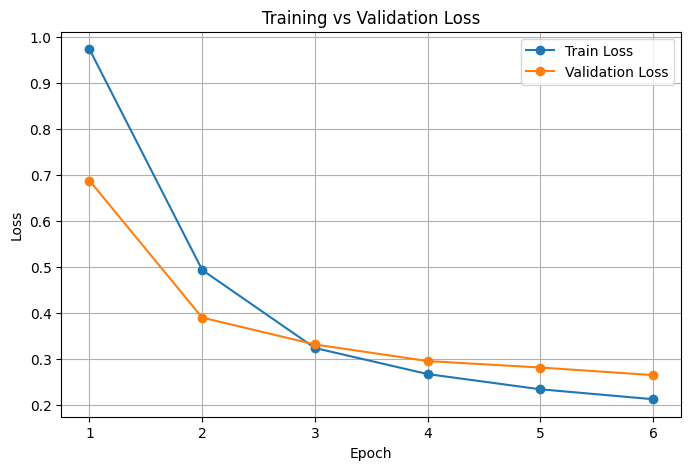

In [7]:
log_history = trainer.state.log_history

train_loss_logs = [x for x in log_history if "loss" in x and "epoch" in x and "eval_loss" not in x]
eval_loss_logs = [x for x in log_history if "eval_loss" in x and "epoch" in x]

train_epochs = [x["epoch"] for x in train_loss_logs]
train_losses = [x["loss"] for x in train_loss_logs]

eval_epochs = [x["epoch"] for x in eval_loss_logs]
eval_losses = [x["eval_loss"] for x in eval_loss_logs]

plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_losses, marker="o", label="Train Loss")
plt.plot(eval_epochs, eval_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# same model  but with lstm

In [8]:
# If needed:
# !pip install -q transformers datasets accelerate scikit-learn matplotlib

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

MODEL_NAME = "faisalq/EgyBERT"
MAX_LEN = 256
OUTPUT_DIR = "./egybert_bilstm_absa_model"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if "train_final" not in globals():
    train_final = pd.read_csv("train_absa_final.csv")

if "validation_final" not in globals():
    validation_final = pd.read_csv("validation_absa_final.csv")

train_df = train_final[["model_input", "sentiment_label"]].dropna().copy()
valid_df = validation_final[["model_input", "sentiment_label"]].dropna().copy()

train_df["sentiment_label"] = train_df["sentiment_label"].astype(int)
valid_df["sentiment_label"] = valid_df["sentiment_label"].astype(int)

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive",
}
label2id = {v: k for k, v in id2label.items()}

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
valid_ds = Dataset.from_pandas(valid_df, preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["model_input"],
        truncation=True,
        max_length=MAX_LEN,
    )

train_ds = train_ds.map(tokenize_function, batched=True)
valid_ds = valid_ds.map(tokenize_function, batched=True)

train_ds = train_ds.rename_column("sentiment_label", "labels")
valid_ds = valid_ds.rename_column("sentiment_label", "labels")

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
valid_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

class EgyBERTBiLSTM(nn.Module):
    def __init__(self, model_name, num_labels, lstm_hidden_size=256, lstm_layers=1, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size

        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden_size * 2, num_labels)
        self.loss_fn = nn.CrossEntropyLoss()

        self.config = self.bert.config
        self.num_labels = num_labels

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state

        lstm_output, (hidden, cell) = self.lstm(sequence_output)

        # Concatenate the last hidden states from both directions
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        pooled_output = torch.cat((forward_hidden, backward_hidden), dim=1)

        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}

model = EgyBERTBiLSTM(
    model_name=MODEL_NAME,
    num_labels=3,
    lstm_hidden_size=256,
    lstm_layers=1,
    dropout=0.3,
).to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_micro": precision_micro,
        "recall_micro": recall_micro,
        "f1_micro": f1_micro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    num_train_epochs=6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Model saved to: {OUTPUT_DIR}")


Using device: cuda
Train shape: (3333, 2)
Validation shape: (840, 2)


Map:   0%|          | 0/3333 [00:00<?, ? examples/s]

Map:   0%|          | 0/840 [00:00<?, ? examples/s]

  0%|          | 0/2502 [00:00<?, ?it/s]

{'loss': 0.8011, 'grad_norm': 13.233463287353516, 'learning_rate': 1.856063971568192e-05, 'epoch': 1.0}


...

{'eval_loss': 0.3019556999206543, 'eval_accuracy': 0.9107142857142857, 'eval_precision_macro': 0.9462558762903397, 'eval_recall_macro': 0.7236887531536317, 'eval_f1_macro': 0.7703079199418879, 'eval_precision_micro': 0.9107142857142857, 'eval_recall_micro': 0.9107142857142857, 'eval_f1_micro': 0.9107142857142857, 'eval_precision_weighted': 0.918423690572213, 'eval_recall_weighted': 0.9107142857142857, 'eval_f1_weighted': 0.9028722915127433, 'eval_runtime': 2.9522, 'eval_samples_per_second': 284.53, 'eval_steps_per_second': 35.566, 'epoch': 3.0}
{'loss': 0.2342, 'grad_norm': 0.08153640478849411, 'learning_rate': 7.4455797423367396e-06, 'epoch': 4.0}


  0%|          | 0/105 [00:00<?, ?it/s]

{'eval_loss': 0.32313981652259827, 'eval_accuracy': 0.9142857142857143, 'eval_precision_macro': 0.917920888910956, 'eval_recall_macro': 0.7279399645486486, 'eval_f1_macro': 0.7696602776677347, 'eval_precision_micro': 0.9142857142857143, 'eval_recall_micro': 0.9142857142857143, 'eval_f1_micro': 0.9142857142857143, 'eval_precision_weighted': 0.9148747202921191, 'eval_recall_weighted': 0.9142857142857143, 'eval_f1_weighted': 0.9064443989230472, 'eval_runtime': 2.9696, 'eval_samples_per_second': 282.864, 'eval_steps_per_second': 35.358, 'epoch': 4.0}
{'loss': 0.203, 'grad_norm': 5.134259223937988, 'learning_rate': 3.7405597512216796e-06, 'epoch': 5.0}


  0%|          | 0/105 [00:00<?, ?it/s]

{'eval_loss': 0.3006875813007355, 'eval_accuracy': 0.9071428571428571, 'eval_precision_macro': 0.7883488419544183, 'eval_recall_macro': 0.7447178645724656, 'eval_f1_macro': 0.7621905816907134, 'eval_precision_micro': 0.9071428571428571, 'eval_recall_micro': 0.9071428571428571, 'eval_f1_micro': 0.9071428571428571, 'eval_precision_weighted': 0.902804872014051, 'eval_recall_weighted': 0.9071428571428571, 'eval_f1_weighted': 0.9036126323655606, 'eval_runtime': 2.8364, 'eval_samples_per_second': 296.148, 'eval_steps_per_second': 37.019, 'epoch': 5.0}
{'train_runtime': 322.5365, 'train_samples_per_second': 62.002, 'train_steps_per_second': 7.757, 'train_loss': 0.3620891470417416, 'epoch': 5.0}
Model saved to: ./egybert_bilstm_absa_model


In [9]:
def evaluate_split(trainer, dataset, split_name):
    pred_output = trainer.predict(dataset)
    preds = np.argmax(pred_output.predictions, axis=-1)
    labels = pred_output.label_ids

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    print(f"\n===== {split_name.upper()} METRICS =====")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision Macro   : {precision_macro:.4f}")
    print(f"Recall Macro      : {recall_macro:.4f}")
    print(f"F1 Macro          : {f1_macro:.4f}")
    print(f"Precision Micro   : {precision_micro:.4f}")
    print(f"Recall Micro      : {recall_micro:.4f}")
    print(f"F1 Micro          : {f1_micro:.4f}")
    print(f"Precision Weighted: {precision_weighted:.4f}")
    print(f"Recall Weighted   : {recall_weighted:.4f}")
    print(f"F1 Weighted       : {f1_weighted:.4f}")

    print(f"\n{split_name.upper()} Classification Report:")
    print(classification_report(
        labels,
        preds,
        target_names=[id2label[0], id2label[1], id2label[2]],
        digits=4,
        zero_division=0
    ))

    print(f"{split_name.upper()} Confusion Matrix:")
    print(confusion_matrix(labels, preds))

train_metrics = evaluate_split(trainer, train_ds, "train")
valid_metrics = evaluate_split(trainer, valid_ds, "validation")


  0%|          | 0/417 [00:00<?, ?it/s]


===== TRAIN METRICS =====
Accuracy          : 0.9430
Precision Macro   : 0.9626
Recall Macro      : 0.7814
F1 Macro          : 0.8304
Precision Micro   : 0.9430
Recall Micro      : 0.9430
F1 Micro          : 0.9430
Precision Weighted: 0.9456
Recall Weighted   : 0.9430
F1 Weighted       : 0.9382

TRAIN Classification Report:
              precision    recall  f1-score   support

    negative     0.9702    0.9525    0.9613      1538
     neutral     1.0000    0.4094    0.5810       149
    positive     0.9177    0.9824    0.9489      1646

    accuracy                         0.9430      3333
   macro avg     0.9626    0.7814    0.8304      3333
weighted avg     0.9456    0.9430    0.9382      3333

TRAIN Confusion Matrix:
[[1465    0   73]
 [  16   61   72]
 [  29    0 1617]]


  0%|          | 0/105 [00:00<?, ?it/s]


===== VALIDATION METRICS =====
Accuracy          : 0.9107
Precision Macro   : 0.9463
Recall Macro      : 0.7237
F1 Macro          : 0.7703
Precision Micro   : 0.9107
Recall Micro      : 0.9107
F1 Micro          : 0.9107
Precision Weighted: 0.9184
Recall Weighted   : 0.9107
F1 Weighted       : 0.9029

VALIDATION Classification Report:
              precision    recall  f1-score   support

    negative     0.9663    0.8824    0.9224       357
     neutral     1.0000    0.3000    0.4615        40
    positive     0.8725    0.9887    0.9270       443

    accuracy                         0.9107       840
   macro avg     0.9463    0.7237    0.7703       840
weighted avg     0.9184    0.9107    0.9029       840

VALIDATION Confusion Matrix:
[[315   0  42]
 [  6  12  22]
 [  5   0 438]]


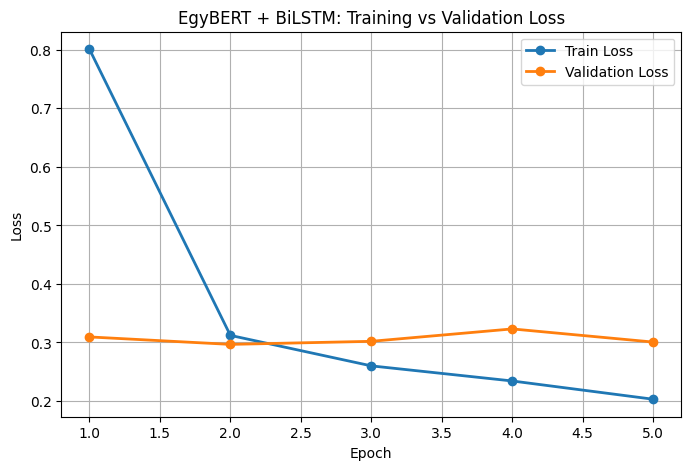

In [10]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss_logs = [
    x for x in log_history
    if "loss" in x and "epoch" in x and "eval_loss" not in x
]

eval_loss_logs = [
    x for x in log_history
    if "eval_loss" in x and "epoch" in x
]

train_epochs = [x["epoch"] for x in train_loss_logs]
train_losses = [x["loss"] for x in train_loss_logs]

eval_epochs = [x["epoch"] for x in eval_loss_logs]
eval_losses = [x["eval_loss"] for x in eval_loss_logs]

plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_losses, marker="o", linewidth=2, label="Train Loss")
plt.plot(eval_epochs, eval_losses, marker="o", linewidth=2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EgyBERT + BiLSTM: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# MARBERTv2 model 

In [12]:
# If needed:
# !pip install -q transformers datasets accelerate scikit-learn matplotlib

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

MODEL_NAME = "UBC-NLP/MARBERTv2"
MAX_LEN = 256
OUTPUT_DIR = "./marbertv2_absa_model"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available, training will run on CPU.")

if "train_final" not in globals():
    train_final = pd.read_csv("train_absa_final.csv")

if "validation_final" not in globals():
    validation_final = pd.read_csv("validation_absa_final.csv")

train_df = train_final[["model_input", "sentiment_label"]].dropna().copy()
valid_df = validation_final[["model_input", "sentiment_label"]].dropna().copy()

train_df["sentiment_label"] = train_df["sentiment_label"].astype(int)
valid_df["sentiment_label"] = valid_df["sentiment_label"].astype(int)

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive",
}
label2id = {v: k for k, v in id2label.items()}

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("\nTrain label distribution:")
print(train_df["sentiment_label"].value_counts().sort_index())
print("\nValidation label distribution:")
print(valid_df["sentiment_label"].value_counts().sort_index())

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
valid_ds = Dataset.from_pandas(valid_df, preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["model_input"],
        truncation=True,
        max_length=MAX_LEN,
    )

train_ds = train_ds.map(tokenize_function, batched=True)
valid_ds = valid_ds.map(tokenize_function, batched=True)

train_ds = train_ds.rename_column("sentiment_label", "labels")
valid_ds = valid_ds.rename_column("sentiment_label", "labels")

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
valid_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

model.to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_micro": precision_micro,
        "recall_micro": recall_micro,
        "f1_micro": f1_micro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    num_train_epochs=6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_pin_memory=torch.cuda.is_available(),
    no_cuda=not torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"\nModel saved to: {OUTPUT_DIR}")


Using device: cuda
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU
Train shape: (3333, 2)
Validation shape: (840, 2)

Train label distribution:
sentiment_label
0    1538
1     149
2    1646
Name: count, dtype: int64

Validation label distribution:
sentiment_label
0    357
1     40
2    443
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

c:\Users\reemb\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\reemb\.cache\huggingface\hub\models--UBC-NLP--MARBERTv2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

{'eval_loss': 0.24572180211544037, 'eval_accuracy': 0.9345238095238095, 'eval_precision_macro': 0.8733809988847036, 'eval_recall_macro': 0.7948853205691607, 'eval_f1_macro': 0.8246669255859628, 'eval_precision_micro': 0.9345238095238095, 'eval_recall_micro': 0.9345238095238095, 'eval_f1_micro': 0.9345238095238095, 'eval_precision_weighted': 0.9321206726315266, 'eval_recall_weighted': 0.9345238095238095, 'eval_f1_weighted': 0.9313986883527366, 'eval_runtime': 1.9608, 'eval_samples_per_second': 428.393, 'eval_steps_per_second': 53.549, 'epoch': 3.0}
{'loss': 0.147, 'grad_norm': 0.030643783509731293, 'learning_rate': 7.4455797423367396e-06, 'epoch': 4.0}


  0%|          | 0/105 [00:00<?, ?it/s]

{'eval_loss': 0.2928105890750885, 'eval_accuracy': 0.9333333333333333, 'eval_precision_macro': 0.8592290347688629, 'eval_recall_macro': 0.7582223107452161, 'eval_f1_macro': 0.7891844800017269, 'eval_precision_micro': 0.9333333333333333, 'eval_recall_micro': 0.9333333333333333, 'eval_f1_micro': 0.9333333333333333, 'eval_precision_weighted': 0.9276425699910931, 'eval_recall_weighted': 0.9333333333333333, 'eval_f1_weighted': 0.9275721592337144, 'eval_runtime': 2.2739, 'eval_samples_per_second': 369.406, 'eval_steps_per_second': 46.176, 'epoch': 4.0}
{'loss': 0.083, 'grad_norm': 0.02567773312330246, 'learning_rate': 3.7405597512216796e-06, 'epoch': 5.0}


  0%|          | 0/105 [00:00<?, ?it/s]

{'eval_loss': 0.2869122326374054, 'eval_accuracy': 0.9428571428571428, 'eval_precision_macro': 0.8537861587854235, 'eval_recall_macro': 0.8019650523866432, 'eval_f1_macro': 0.8230534639570345, 'eval_precision_micro': 0.9428571428571428, 'eval_recall_micro': 0.9428571428571428, 'eval_f1_micro': 0.9428571428571428, 'eval_precision_weighted': 0.9389520781732569, 'eval_recall_weighted': 0.9428571428571428, 'eval_f1_weighted': 0.9401661905147454, 'eval_runtime': 2.0065, 'eval_samples_per_second': 418.629, 'eval_steps_per_second': 52.329, 'epoch': 5.0}
{'train_runtime': 290.8135, 'train_samples_per_second': 68.766, 'train_steps_per_second': 8.603, 'train_loss': 0.24169782460164682, 'epoch': 5.0}

Model saved to: ./marbertv2_absa_model


In [13]:
def evaluate_split(trainer, dataset, split_name):
    pred_output = trainer.predict(dataset)
    preds = np.argmax(pred_output.predictions, axis=-1)
    labels = pred_output.label_ids

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    print(f"\n===== {split_name.upper()} METRICS =====")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision Macro   : {precision_macro:.4f}")
    print(f"Recall Macro      : {recall_macro:.4f}")
    print(f"F1 Macro          : {f1_macro:.4f}")
    print(f"Precision Micro   : {precision_micro:.4f}")
    print(f"Recall Micro      : {recall_micro:.4f}")
    print(f"F1 Micro          : {f1_micro:.4f}")
    print(f"Precision Weighted: {precision_weighted:.4f}")
    print(f"Recall Weighted   : {recall_weighted:.4f}")
    print(f"F1 Weighted       : {f1_weighted:.4f}")

    print(f"\n{split_name.upper()} Classification Report:")
    print(classification_report(
        labels,
        preds,
        target_names=[id2label[0], id2label[1], id2label[2]],
        digits=4,
        zero_division=0
    ))

    print(f"{split_name.upper()} Confusion Matrix:")
    print(confusion_matrix(labels, preds))

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_micro": precision_micro,
        "recall_micro": recall_micro,
        "f1_micro": f1_micro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

train_metrics = evaluate_split(trainer, train_ds, "train")
valid_metrics = evaluate_split(trainer, valid_ds, "validation")

print("\n===== FIT DIAGNOSIS =====")
train_f1 = train_metrics["f1_macro"]
valid_f1 = valid_metrics["f1_macro"]
gap = train_f1 - valid_f1

print(f"Train F1 Macro     : {train_f1:.4f}")
print(f"Validation F1 Macro: {valid_f1:.4f}")
print(f"Generalization Gap : {gap:.4f}")

if gap > 0.10:
    print("Possible overfitting: train score is much higher than validation.")
elif train_f1 < 0.60 and valid_f1 < 0.60:
    print("Possible underfitting: both train and validation scores are low.")
else:
    print("No strong sign of overfitting or underfitting from macro F1 gap.")


  0%|          | 0/417 [00:00<?, ?it/s]


===== TRAIN METRICS =====
Accuracy          : 0.9691
Precision Macro   : 0.9589
Recall Macro      : 0.8788
F1 Macro          : 0.9115
Precision Micro   : 0.9691
Recall Micro      : 0.9691
F1 Micro          : 0.9691
Precision Weighted: 0.9690
Recall Weighted   : 0.9691
F1 Weighted       : 0.9679

TRAIN Classification Report:
              precision    recall  f1-score   support

    negative     0.9855    0.9707    0.9781      1538
     neutral     0.9346    0.6711    0.7812       149
    positive     0.9568    0.9945    0.9753      1646

    accuracy                         0.9691      3333
   macro avg     0.9589    0.8788    0.9115      3333
weighted avg     0.9690    0.9691    0.9679      3333

TRAIN Confusion Matrix:
[[1493    7   38]
 [  13  100   36]
 [   9    0 1637]]


  0%|          | 0/105 [00:00<?, ?it/s]


===== VALIDATION METRICS =====
Accuracy          : 0.9345
Precision Macro   : 0.8734
Recall Macro      : 0.7949
F1 Macro          : 0.8247
Precision Micro   : 0.9345
Recall Micro      : 0.9345
F1 Micro          : 0.9345
Precision Weighted: 0.9321
Recall Weighted   : 0.9345
F1 Weighted       : 0.9314

VALIDATION Classification Report:
              precision    recall  f1-score   support

    negative     0.9679    0.9300    0.9486       357
     neutral     0.7308    0.4750    0.5758        40
    positive     0.9214    0.9797    0.9497       443

    accuracy                         0.9345       840
   macro avg     0.8734    0.7949    0.8247       840
weighted avg     0.9321    0.9345    0.9314       840

VALIDATION Confusion Matrix:
[[332   5  20]
 [  4  19  17]
 [  7   2 434]]

===== FIT DIAGNOSIS =====
Train F1 Macro     : 0.9115
Validation F1 Macro: 0.8247
Generalization Gap : 0.0869
No strong sign of overfitting or underfitting from macro F1 gap.


   epoch  train_loss  val_loss
0    1.0      0.5008  0.383068
1    2.0      0.2748  0.263940
2    3.0      0.2029  0.245722
3    4.0      0.1470  0.292811
4    5.0      0.0830  0.286912


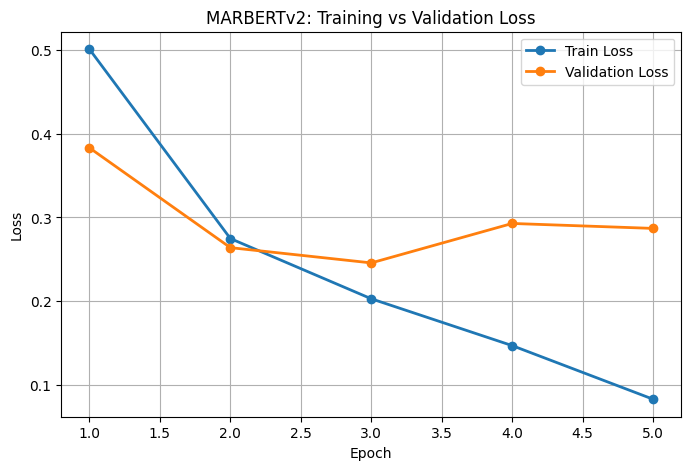

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss_logs = [
    x for x in log_history
    if "loss" in x and "epoch" in x and "eval_loss" not in x
]

eval_loss_logs = [
    x for x in log_history
    if "eval_loss" in x and "epoch" in x
]

train_df_loss = pd.DataFrame({
    "epoch": [x["epoch"] for x in train_loss_logs],
    "train_loss": [x["loss"] for x in train_loss_logs],
})

eval_df_loss = pd.DataFrame({
    "epoch": [x["epoch"] for x in eval_loss_logs],
    "val_loss": [x["eval_loss"] for x in eval_loss_logs],
})

loss_df = pd.merge(train_df_loss, eval_df_loss, on="epoch", how="outer").sort_values("epoch")
print(loss_df)

plt.figure(figsize=(8, 5))
plt.plot(loss_df["epoch"], loss_df["train_loss"], marker="o", linewidth=2, label="Train Loss")
plt.plot(loss_df["epoch"], loss_df["val_loss"], marker="o", linewidth=2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MARBERTv2: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# MARBERTv2 model with lstm

In [15]:
# If needed:
# !pip install -q transformers datasets accelerate scikit-learn matplotlib

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

MODEL_NAME = "UBC-NLP/MARBERTv2"
MAX_LEN = 256
OUTPUT_DIR = "./marbertv2_lstm_absa_model"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available, training will run on CPU.")

if "train_final" not in globals():
    train_final = pd.read_csv("train_absa_final.csv")

if "validation_final" not in globals():
    validation_final = pd.read_csv("validation_absa_final.csv")

train_df = train_final[["model_input", "sentiment_label"]].dropna().copy()
valid_df = validation_final[["model_input", "sentiment_label"]].dropna().copy()

train_df["sentiment_label"] = train_df["sentiment_label"].astype(int)
valid_df["sentiment_label"] = valid_df["sentiment_label"].astype(int)

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive",
}
label2id = {v: k for k, v in id2label.items()}

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("\nTrain label distribution:")
print(train_df["sentiment_label"].value_counts().sort_index())
print("\nValidation label distribution:")
print(valid_df["sentiment_label"].value_counts().sort_index())

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
valid_ds = Dataset.from_pandas(valid_df, preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["model_input"],
        truncation=True,
        max_length=MAX_LEN,
    )

train_ds = train_ds.map(tokenize_function, batched=True)
valid_ds = valid_ds.map(tokenize_function, batched=True)

train_ds = train_ds.rename_column("sentiment_label", "labels")
valid_ds = valid_ds.rename_column("sentiment_label", "labels")

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
valid_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])


class MARBERTv2LSTM(nn.Module):
    def __init__(self, model_name, num_labels=3, lstm_hidden_size=150):
        super().__init__()
        self.marbert = AutoModel.from_pretrained(model_name)
        hidden_size = self.marbert.config.hidden_size

        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=lstm_hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=False,
        )

        self.relu = nn.ReLU()
        self.classifier = nn.Linear(lstm_hidden_size, num_labels)
        self.loss_fn = nn.CrossEntropyLoss()

        self.config = self.marbert.config
        self.num_labels = num_labels

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = self.marbert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state

        lstm_output, (hidden, cell) = self.lstm(sequence_output)

        # Paper-style summary: use the last hidden state from the LSTM
        last_hidden = hidden[-1]
        features = self.relu(last_hidden)
        logits = self.classifier(features)

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}


model = MARBERTv2LSTM(
    model_name=MODEL_NAME,
    num_labels=3,
    lstm_hidden_size=150,   # matches the paper's 150 LSTM units
).to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_micro": precision_micro,
        "recall_micro": recall_micro,
        "f1_micro": f1_micro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    num_train_epochs=6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    no_cuda=not torch.cuda.is_available(),
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"\nModel saved to: {OUTPUT_DIR}")


Using device: cuda
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU
Train shape: (3333, 2)
Validation shape: (840, 2)

Train label distribution:
sentiment_label
0    1538
1     149
2    1646
Name: count, dtype: int64

Validation label distribution:
sentiment_label
0    357
1     40
2    443
Name: count, dtype: int64


Map:   0%|          | 0/3333 [00:00<?, ? examples/s]

Map:   0%|          | 0/840 [00:00<?, ? examples/s]

  0%|          | 0/2502 [00:00<?, ?it/s]

{'loss': 0.6165, 'grad_norm': 1.6217708587646484, 'learning_rate': 1.8551754775655265e-05, 'epoch': 1.0}


...

{'eval_loss': 0.2624446451663971, 'eval_accuracy': 0.930952380952381, 'eval_precision_macro': 0.8620191014258811, 'eval_recall_macro': 0.7781912539282079, 'eval_f1_macro': 0.8081546592224788, 'eval_precision_micro': 0.930952380952381, 'eval_recall_micro': 0.930952380952381, 'eval_f1_micro': 0.930952380952381, 'eval_precision_weighted': 0.9268308735923748, 'eval_recall_weighted': 0.930952380952381, 'eval_f1_weighted': 0.9269774901008728, 'eval_runtime': 2.3239, 'eval_samples_per_second': 361.464, 'eval_steps_per_second': 45.183, 'epoch': 4.0}
{'loss': 0.1538, 'grad_norm': 0.3000314235687256, 'learning_rate': 3.7405597512216796e-06, 'epoch': 5.0}


  0%|          | 0/105 [00:00<?, ?it/s]

{'eval_loss': 0.2611978352069855, 'eval_accuracy': 0.9333333333333333, 'eval_precision_macro': 0.8517974562035037, 'eval_recall_macro': 0.7872770327092461, 'eval_f1_macro': 0.8123452851364013, 'eval_precision_micro': 0.9333333333333333, 'eval_recall_micro': 0.9333333333333333, 'eval_f1_micro': 0.9333333333333333, 'eval_precision_weighted': 0.9295382769378451, 'eval_recall_weighted': 0.9333333333333333, 'eval_f1_weighted': 0.9301511860190663, 'eval_runtime': 2.0364, 'eval_samples_per_second': 412.491, 'eval_steps_per_second': 51.561, 'epoch': 5.0}
{'loss': 0.1167, 'grad_norm': 2.24072265625, 'learning_rate': 3.553976010661928e-08, 'epoch': 6.0}


  0%|          | 0/105 [00:00<?, ?it/s]

{'eval_loss': 0.2493407428264618, 'eval_accuracy': 0.9345238095238095, 'eval_precision_macro': 0.8349088468642698, 'eval_recall_macro': 0.8037350380332721, 'eval_f1_macro': 0.817569186287991, 'eval_precision_micro': 0.9345238095238095, 'eval_recall_micro': 0.9345238095238095, 'eval_f1_micro': 0.9345238095238095, 'eval_precision_weighted': 0.9318597596579901, 'eval_recall_weighted': 0.9345238095238095, 'eval_f1_weighted': 0.9328614132220824, 'eval_runtime': 2.0679, 'eval_samples_per_second': 406.203, 'eval_steps_per_second': 50.775, 'epoch': 6.0}
{'train_runtime': 618.8175, 'train_samples_per_second': 32.316, 'train_steps_per_second': 4.043, 'train_loss': 0.2720601472923224, 'epoch': 6.0}

Model saved to: ./marbertv2_lstm_absa_model


In [16]:
def evaluate_split(trainer, dataset, split_name):
    pred_output = trainer.predict(dataset)
    preds = np.argmax(pred_output.predictions, axis=-1)
    labels = pred_output.label_ids

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
        labels, preds, average="micro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    print(f"\n===== {split_name.upper()} METRICS =====")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision Macro   : {precision_macro:.4f}")
    print(f"Recall Macro      : {recall_macro:.4f}")
    print(f"F1 Macro          : {f1_macro:.4f}")
    print(f"Precision Micro   : {precision_micro:.4f}")
    print(f"Recall Micro      : {recall_micro:.4f}")
    print(f"F1 Micro          : {f1_micro:.4f}")
    print(f"Precision Weighted: {precision_weighted:.4f}")
    print(f"Recall Weighted   : {recall_weighted:.4f}")
    print(f"F1 Weighted       : {f1_weighted:.4f}")

    print(f"\n{split_name.upper()} Classification Report:")
    print(classification_report(
        labels,
        preds,
        target_names=[id2label[0], id2label[1], id2label[2]],
        digits=4,
        zero_division=0
    ))

    print(f"{split_name.upper()} Confusion Matrix:")
    print(confusion_matrix(labels, preds))

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_micro": precision_micro,
        "recall_micro": recall_micro,
        "f1_micro": f1_micro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

train_metrics = evaluate_split(trainer, train_ds, "train")
valid_metrics = evaluate_split(trainer, valid_ds, "validation")

print("\n===== FIT DIAGNOSIS =====")
train_f1 = train_metrics["f1_macro"]
valid_f1 = valid_metrics["f1_macro"]
gap = train_f1 - valid_f1

print(f"Train F1 Macro     : {train_f1:.4f}")
print(f"Validation F1 Macro: {valid_f1:.4f}")
print(f"Generalization Gap : {gap:.4f}")

if gap > 0.10:
    print("Possible overfitting: train score is much higher than validation.")
elif train_f1 < 0.60 and valid_f1 < 0.60:
    print("Possible underfitting: both train and validation scores are low.")
else:
    print("No strong sign of overfitting or underfitting from macro F1 gap.")


  0%|          | 0/417 [00:00<?, ?it/s]


===== TRAIN METRICS =====
Accuracy          : 0.9820
Precision Macro   : 0.9780
Recall Macro      : 0.9367
F1 Macro          : 0.9556
Precision Micro   : 0.9820
Recall Micro      : 0.9820
F1 Micro          : 0.9820
Precision Weighted: 0.9819
Recall Weighted   : 0.9820
F1 Weighted       : 0.9817

TRAIN Classification Report:
              precision    recall  f1-score   support

    negative     0.9844    0.9870    0.9857      1538
     neutral     0.9688    0.8322    0.8953       149
    positive     0.9808    0.9909    0.9858      1646

    accuracy                         0.9820      3333
   macro avg     0.9780    0.9367    0.9556      3333
weighted avg     0.9819    0.9820    0.9817      3333

TRAIN Confusion Matrix:
[[1518    1   19]
 [  12  124   13]
 [  12    3 1631]]


  0%|          | 0/105 [00:00<?, ?it/s]


===== VALIDATION METRICS =====
Accuracy          : 0.9345
Precision Macro   : 0.8349
Recall Macro      : 0.8037
F1 Macro          : 0.8176
Precision Micro   : 0.9345
Recall Micro      : 0.9345
F1 Micro          : 0.9345
Precision Weighted: 0.9319
Recall Weighted   : 0.9345
F1 Weighted       : 0.9329

VALIDATION Classification Report:
              precision    recall  f1-score   support

    negative     0.9603    0.9496    0.9549       357
     neutral     0.6061    0.5000    0.5479        40
    positive     0.9383    0.9616    0.9498       443

    accuracy                         0.9345       840
   macro avg     0.8349    0.8037    0.8176       840
weighted avg     0.9319    0.9345    0.9329       840

VALIDATION Confusion Matrix:
[[339   5  13]
 [  5  20  15]
 [  9   8 426]]

===== FIT DIAGNOSIS =====
Train F1 Macro     : 0.9556
Validation F1 Macro: 0.8176
Generalization Gap : 0.1380
Possible overfitting: train score is much higher than validation.


   epoch  train_loss  val_loss
0    1.0      0.6165  0.376633
1    2.0      0.3007  0.296197
2    3.0      0.2457  0.319275
3    4.0      0.1989  0.262445
4    5.0      0.1538  0.261198
5    6.0      0.1167  0.249341


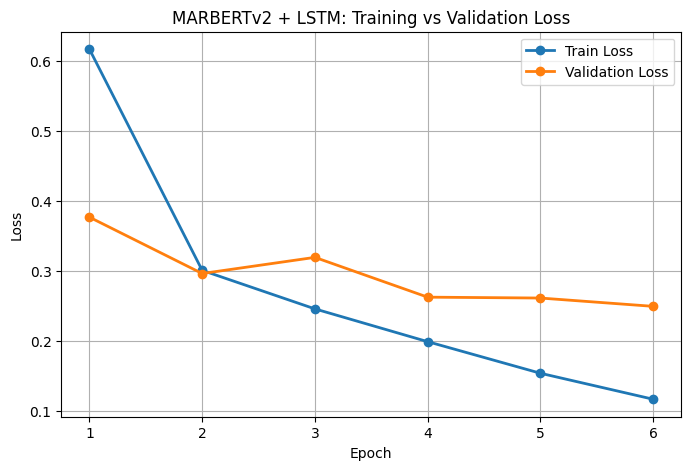

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss_logs = [
    x for x in log_history
    if "loss" in x and "epoch" in x and "eval_loss" not in x
]

eval_loss_logs = [
    x for x in log_history
    if "eval_loss" in x and "epoch" in x
]

train_df_loss = pd.DataFrame({
    "epoch": [x["epoch"] for x in train_loss_logs],
    "train_loss": [x["loss"] for x in train_loss_logs],
})

eval_df_loss = pd.DataFrame({
    "epoch": [x["epoch"] for x in eval_loss_logs],
    "val_loss": [x["eval_loss"] for x in eval_loss_logs],
})

loss_df = pd.merge(train_df_loss, eval_df_loss, on="epoch", how="outer").sort_values("epoch")
print(loss_df)

plt.figure(figsize=(8, 5))
plt.plot(loss_df["epoch"], loss_df["train_loss"], marker="o", linewidth=2, label="Train Loss")
plt.plot(loss_df["epoch"], loss_df["val_loss"], marker="o", linewidth=2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MARBERTv2 + LSTM: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()
